# Food–Microbiome Linkage

Goal of this notebook: link the two project datasets (cFMD and dietstudy) by
building a new unified key column (`food_category_unified`), since no shared
field exists between them natively.

## Step 1: Extract unique values from both sides

Before building any mapping, we need to know exactly what we're working with:
- All unique (L1, L2) USDA taxonomy pairs that actually appear in the food diaries
- All unique macrocategory/category/subtype values in cFMD, including sample
  counts per value (to identify where real data overlap exists)

In [35]:
import pandas as pd
from pathlib import Path
import numpy as np

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 80)

BASE = Path("dietstudy_analyses-master")
FOOD_DIR = BASE / "data" / "procrustes" / "data_username_1day"

# ---------- Dataset 2: extract L1/L2 from the USDA taxonomy strings ----------
food_files = sorted(FOOD_DIR.glob("*_food.txt"))

usda_rows = []
for fp in food_files:
    df = pd.read_csv(fp, sep="\t", usecols=["#FoodID", "taxonomy"])
    usda_rows.append(df)

usda_all = pd.concat(usda_rows, ignore_index=True).drop_duplicates(subset="#FoodID")

def extract_level(taxonomy, level_idx):
    parts = str(taxonomy).split(";")
    if level_idx < len(parts):
        return parts[level_idx].replace(f"L{level_idx+1}_", "").strip()
    return "Unknown"

usda_all["L1"] = usda_all["taxonomy"].apply(lambda t: extract_level(t, 0))
usda_all["L2"] = usda_all["taxonomy"].apply(lambda t: extract_level(t, 1))

usda_l1_l2_counts = (
    usda_all.groupby(["L1", "L2"])["#FoodID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="NumUniqueFoods")
)

print(f"Total unique food items in diary taxonomy: {usda_all['#FoodID'].nunique()}")
print(f"Total unique (L1, L2) pairs: {len(usda_l1_l2_counts)}")
print()
usda_l1_l2_counts

Total unique food items in diary taxonomy: 1452
Total unique (L1, L2) pairs: 45



,L1,L2,NumUniqueFoods
0,Vegetables,Other_vegetables,190
1,Grain_Product,Grain_mixtures_frozen_plate_meals_soups,132
2,Grain_Product,Cakes_cookies_pies_pastries_bars,81
3,Meat_Poultry_Fish_and_Mixtures,Meatpoultry_fish_with_nonmeat,71
4,Grain_Product,Yeast,64
5,Sugars_Sweets_and_Beverages,Nonalcoholic_beverages,59
6,Sugars_Sweets_and_Beverages,Sugars_and_sweets,57
7,Meat_Poultry_Fish_and_Mixtures,Poultry,42
8,Fruits,Other_fruits,42
9,Vegetables,White_potatoes_and_Puerto_Rican_starchy_vegetables,41


In [2]:
# ---------- Dataset 1: unique cFMD category values + sample counts ----------
cfmd_metadata = pd.read_csv("master_metadata.tsv", sep="\t")

cfmd_category_counts = (
    cfmd_metadata.groupby(["macrocategory", "category"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="NumSamples")
)

print(f"Total cFMD samples: {len(cfmd_metadata)}")
print(f"Total unique (macrocategory, category) pairs: {len(cfmd_category_counts)}")
print()
cfmd_category_counts

Total cFMD samples: 3441
Total unique (macrocategory, category) pairs: 15



,macrocategory,category,NumSamples
0,food,dairy,2296
1,food,fermented_beverages,435
2,food,fermented_meat,156
3,food,meat,119
4,food,fish,91
5,food,fermented_grains,83
6,food,fermented_seeds,65
7,food,fermented_fruits_and_vegetables,52
8,food,alcohol,48
9,food,fruits_and_vegetables,25


## Step 1b: Inspect subtype breakdown within the largest cFMD categories

Before committing to a mapping, we check whether the largest categories
(`dairy`, `fermented_fruits_and_vegetables`, `fermented_grains`) are
homogeneous (all genuinely fermented) or mixed with non-fermented items,
since this directly affects whether matching them to USDA categories is valid.

In [3]:
for cat in ["dairy", "fermented_fruits_and_vegetables", "fermented_grains", "fermented_legumes"]:
    subset = cfmd_metadata[cfmd_metadata["category"] == cat]
    print(f"=== category = {cat} (n={len(subset)}) ===")
    print(subset["subtype"].value_counts().head(15))
    print()

=== category = dairy (n=2296) ===
subtype
milk_kefir                      285
raw_milk_cheese                 128
Cheddar                         102
Cheese_1_before_ripening         97
cheese_2_before_ripening         96
cheese_2_after_ripening          95
Cheese_1_after_ripening          94
whey                             84
raw_milk                         70
Caciocavallo                     66
surface_ripened_soft_cheeses     56
parmigiano_reggiano              53
brine                            53
grana                            50
mozzarella                       49
Name: count, dtype: int64

=== category = fermented_fruits_and_vegetables (n=52) ===
subtype
mixed_vegetable_pickle                         12
green_papaya_pickle                             3
white_onion_pickle                              3
vitis_vinifera_l_cv_corvina_grape_withering     2
carrot_kimchi                                   1
garlic_kraut                                    1
brussels_sprout_kimchi   

## Step 1c: Search USDA food names for fermentation-relevant keywords

Rather than matching whole L1/L2 categories (which are too broad and mostly
non-fermented), we search the actual food item names and L3-L5 levels for
keywords that indicate genuine fermentation, to find the narrow subset of
the diary that has a real fermented-food counterpart in cFMD.

In [4]:
FERMENT_KEYWORDS = [
    "pickle", "kimchi", "sauerkraut", "kraut", "fermented",
    "sourdough", "kefir", "kombucha", "miso", "yogurt", "yoghurt"
]

pattern = "|".join(FERMENT_KEYWORDS)
ferment_matches = usda_all[
    usda_all["taxonomy"].str.contains(pattern, case=False, na=False)
    | usda_all["#FoodID"].str.contains(pattern, case=False, na=False)
]

print(f"USDA food items matching fermentation keywords: {len(ferment_matches)}")
print()
ferment_matches[["#FoodID", "L1", "L2"]].sort_values("L1")

USDA food items matching fermentation keywords: 30



,#FoodID,L1,L2
1213,Soybean soup miso broth,Dry_Beans_Peas_Other_Legumes_Nuts_and_Seeds,Legumes
1436,Yogurt dressing,Fats_Oils_and_Salad_Dressings,Salad_dressings
836,Nature Valley Chewy Granola Bar with Yogurt Coating,Grain_Product,Cakes_cookies_pies_pastries_bars
1449,Yogurt vanilla lemon or coffee flavor whole milk,Milk_and_Milk_Products,Milks_and_milk_drinks
1447,Yogurt vanilla lemon maple or coffee flavor lowfat milk,Milk_and_Milk_Products,Milks_and_milk_drinks
1446,Yogurt plain whole milk,Milk_and_Milk_Products,Milks_and_milk_drinks
1445,Yogurt plain nonfat milk,Milk_and_Milk_Products,Milks_and_milk_drinks
1444,Yogurt plain lowfat milk,Milk_and_Milk_Products,Milks_and_milk_drinks
1443,Yogurt fruit variety whole milk,Milk_and_Milk_Products,Milks_and_milk_drinks
1442,Yogurt fruit variety nonfat milk sweetened with low calorie sweetener,Milk_and_Milk_Products,Milks_and_milk_drinks


## Step 1d: Check for fermented-meat matches (salami, sausage, cured meats)

cFMD's `fermented_meat` category (n=156) may have a counterpart in the diary's
sausage/lunchmeat items. We check explicitly since "sausage" does not contain
any of the previous fermentation keywords.

In [5]:
MEAT_KEYWORDS = ["salami", "sausage", "pepperoni", "prosciutto", "cured", "bologna", "lunchmeat", "ham"]

pattern_meat = "|".join(MEAT_KEYWORDS)
meat_matches = usda_all[
    usda_all["#FoodID"].str.contains(pattern_meat, case=False, na=False)
]

print(f"USDA food items matching meat-curing keywords: {len(meat_matches)}")
print()
meat_matches[["#FoodID", "L1", "L2"]].sort_values("#FoodID")

USDA food items matching meat-curing keywords: 38



,#FoodID,L1,L2
108,Bologna turkey,Meat_Poultry_Fish_and_Mixtures,Organ_meats_sausages_and_lunchmeats
491,Crackers graham,Grain_Product,Crackers_and_salty_snacks_from_grain
539,Deer bologna,Meat_Poultry_Fish_and_Mixtures,Lamb_veal_game_other
552,Egg cheese and ham on bagel,Eggs,Egg_mixtures
553,Egg cheese and sausage on biscuit,Eggs,Egg_mixtures
662,Ham fried NS as to fat eaten,Meat_Poultry_Fish_and_Mixtures,Pork
663,Ham or pork noodles and vegetables excluding carrots broccoli and dark green...,Meat_Poultry_Fish_and_Mixtures,Meatpoultry_fish_with_nonmeat
664,Ham or pork salad,Meat_Poultry_Fish_and_Mixtures,Meatpoultry_fish_with_nonmeat
665,Ham or pork with barbecue sauce mixture,Meat_Poultry_Fish_and_Mixtures,Meatpoultry_fish_with_nonmeat
666,Ham prosciutto,Meat_Poultry_Fish_and_Mixtures,Pork


## Step 1e: Inspect subtype breakdown of cFMD fermented_meat

Before matching salami/pepperoni-type items, we verify what cFMD's
fermented_meat category actually contains, to avoid repeating the mistake
seen with fermented_grains (mostly non-relevant ethnic products).

In [6]:
subset = cfmd_metadata[cfmd_metadata["category"] == "fermented_meat"]
print(f"=== category = fermented_meat (n={len(subset)}) ===")
print(subset["subtype"].value_counts().head(20))

=== category = fermented_meat (n=156) ===
subtype
cured_meat_after_ripening                                           16
felino-type_sausages                                                16
pig_sausage                                                         15
sausage_after_ripening                                              14
salame_felino                                                       10
finocchiona                                                         10
salame_napoli                                                        9
fresh_meat_after_ripening                                            8
calibraton_sausage_containing_cattle_pig_chicken_and_turkey_meat     8
salame_ungherese                                                     7
salame_felino_IGP                                                    6
cacciatore_italiano                                                  6
calibraton_sausage_containing_cattle_pig_sheep_and_horse_meat        4
salame_piacentino          

## Step 2: Build the explicit mapping dictionaries and unified key

Based on the inspection above, we define two lookup tables that map each
side to a shared `food_category_unified` key. Categories with no validated
counterpart (fermented_grains, fermented_legumes, fermented_fish,
fermented_tubers_and_roots) are intentionally excluded — see documentation
for rationale.

In [9]:
# ---------- cFMD side: category -> unified key ----------
# Note: "probiotics" was checked and has zero counterpart in the diary
# (no USDA food item matched it) - excluded to avoid dead code.
CFMD_CATEGORY_MAP = {
    "dairy": "dairy_fermented",
    "fermented_beverages": "beverage_alcoholic_fermented",
    "alcohol": "beverage_alcoholic_fermented",
    "fermented_meat": "meat_cured_fermented",
    "fermented_fruits_and_vegetables": "vegetable_fermented",
}

cfmd_metadata["food_category_unified"] = cfmd_metadata["category"].map(CFMD_CATEGORY_MAP)

print("cFMD samples retained after mapping:")
print(cfmd_metadata["food_category_unified"].value_counts(dropna=False))

cFMD samples retained after mapping:
food_category_unified
dairy_fermented                 2296
beverage_alcoholic_fermented     483
NaN                              454
meat_cured_fermented             156
vegetable_fermented               52
Name: count, dtype: int64


In [8]:
# ---------- USDA side: explicit item-level allow-list per unified key ----------

DAIRY_FERMENTED_ITEMS = [
    # all Cheeses (L2) are fermented dairy products
    "L2_Cheeses",
]
DAIRY_FERMENTED_FOODIDS = [
    "Yogurt vanilla lemon or coffee flavor whole milk",
    "Yogurt vanilla lemon maple or coffee flavor lowfat milk",
    "Yogurt vanilla lemon maple or coffee flavor nonfat milk",
    "Yogurt plain whole milk", "Yogurt plain nonfat milk", "Yogurt plain lowfat milk",
    "Yogurt fruit variety whole milk",
    "Yogurt fruit variety nonfat milk sweetened with low calorie sweetener",
    "Yogurt fruit variety nonfat milk",
    "Yogurt fruit variety lowfat milk sweetened with low calorie sweetener",
    "Yogurt fruit variety lowfat milk",
    "Yogurt frozen NS as to flavor NS as to type of milk",
    "Yogurt frozen flavors other than chocolate lowfat milk",
]  # explicitly excludes "Yogurt dressing" and "...Yogurt Coating" (not real yogurt exposure)

ALCOHOL_FERMENTED_L2 = ["L2_Alcoholic_beverages"]

MEAT_CURED_FOODIDS = [
    "Salami NFS", "Pepperoni", "Italian sausage", "Polish sausage", "Turkey salami",
]  # explicitly excludes Bologna/Ham/Bacon/Pork sausage/Turkey sausage (smoked/cooked, not fermented-cured)

VEGETABLE_FERMENTED_FOODIDS = [
    "Beans string green pickled", "Peppers pickled", "Olives NFS", "Olives green",
    "Olives black", "Cucumber pickles relish", "Cucumber pickles dill reduced salt",
    "Cucumber pickles dill", "Cabbage red pickled", "Beets pickled",
    "Radishes pickled Hawaiian style", "Sauerkraut cooked NS as to fat added in cooking",
]  # excludes "Mustard" and "Hot pepper sauce" (condiments, not whole fermented vegetables)


def assign_unified_category(row):
    food_id = row["#FoodID"]
    if food_id in DAIRY_FERMENTED_FOODIDS or row["L2"] == "Cheeses":
        return "dairy_fermented"
    if row["L2"] == "Alcoholic_beverages":
        return "beverage_alcoholic_fermented"
    if food_id in MEAT_CURED_FOODIDS:
        return "meat_cured_fermented"
    if food_id in VEGETABLE_FERMENTED_FOODIDS:
        return "vegetable_fermented"
    return None


usda_all["food_category_unified"] = usda_all.apply(assign_unified_category, axis=1)

print("USDA diary items retained after mapping:")
print(usda_all["food_category_unified"].value_counts(dropna=False))

USDA diary items retained after mapping:
food_category_unified
None                            1366
dairy_fermented                   50
beverage_alcoholic_fermented      19
vegetable_fermented               12
meat_cured_fermented               5
Name: count, dtype: int64


## Step 3: Compute a microbial signature for each food category

For each of the 4 validated `food_category_unified` groups, we summarize the
microbial richness (number of taxa present) and Shannon diversity across all
cFMD samples belonging to that category. This produces one row per category -
the "microbial fingerprint" that will later be joined to the diary side.

Richness and diversity are computed per-sample first, then averaged across
samples within each category (not the reverse), to avoid letting samples
with many zero-abundance taxa distort the category-level mean.

In [12]:
from scipy.stats import entropy

cfmd_tax = pd.read_csv("master_taxonomic_profiles.tsv", sep="\t", index_col=0)

# The raw file has mixed-type columns (numbers stored as strings in some
# columns) - force everything to numeric, turning any non-numeric value into 0.
cfmd_tax = cfmd_tax.apply(pd.to_numeric, errors="coerce").fillna(0)

# Restrict to samples that have a valid unified category
valid_samples = cfmd_metadata.dropna(subset=["food_category_unified"])

if "combined_id" not in valid_samples.columns:
    valid_samples = valid_samples.copy()
    valid_samples["combined_id"] = (
        valid_samples["dataset_name"] + "__" + valid_samples["sample_id"].astype(str)
    )

valid_samples = valid_samples[valid_samples["combined_id"].isin(cfmd_tax.columns)]
print(f"cFMD samples with valid category AND present in taxonomic table: {len(valid_samples)}")

per_sample_records = []
for _, row in valid_samples.iterrows():
    abundances = cfmd_tax[row["combined_id"]].to_numpy()
    abundances = abundances[abundances > 0]
    if len(abundances) == 0:
        continue
    per_sample_records.append({
        "combined_id": row["combined_id"],
        "food_category_unified": row["food_category_unified"],
        "Richness": len(abundances),
        "ShannonDiversity": entropy(abundances),
    })

per_sample_df = pd.DataFrame(per_sample_records)

category_signature = (
    per_sample_df.groupby("food_category_unified")[["Richness", "ShannonDiversity"]]
    .mean()
    .reset_index()
)
category_signature["NumSamplesUsed"] = (
    per_sample_df.groupby("food_category_unified").size().values
)

print()
category_signature

C:\Users\winte\AppData\Local\Temp\ipykernel_45580\1452544241.py:3: DtypeWarning: Columns (823) have mixed types. Specify dtype option on import or set low_memory=False.
  cfmd_tax = pd.read_csv("master_taxonomic_profiles.tsv", sep="\t", index_col=0)


cFMD samples with valid category AND present in taxonomic table: 2952



,food_category_unified,Richness,ShannonDiversity,NumSamplesUsed
0,beverage_alcoholic_fermented,17.856846,1.297330,482
1,dairy_fermented,25.396118,1.063938,2267
2,meat_cured_fermented,37.410596,1.210545,151
3,vegetable_fermented,31.480769,1.727883,52


## Step 3b: Visualize the microbial signatures

A side-by-side comparison of richness and Shannon diversity across the
4 validated food categories, to sanity-check the result biologically
before using it downstream.

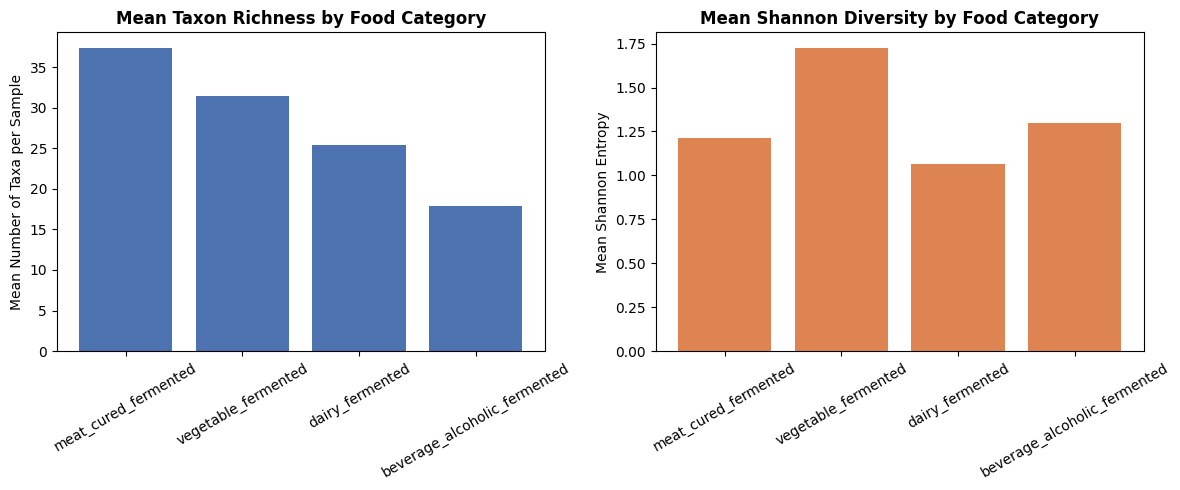

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = category_signature.sort_values("Richness", ascending=False)["food_category_unified"]

axes[0].bar(category_signature.set_index("food_category_unified").loc[order, "Richness"].index,
            category_signature.set_index("food_category_unified").loc[order, "Richness"].values,
            color="#4C72B0")
axes[0].set_title("Mean Taxon Richness by Food Category", fontweight="bold")
axes[0].set_ylabel("Mean Number of Taxa per Sample")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(category_signature.set_index("food_category_unified").loc[order, "ShannonDiversity"].index,
            category_signature.set_index("food_category_unified").loc[order, "ShannonDiversity"].values,
            color="#DD8452")
axes[1].set_title("Mean Shannon Diversity by Food Category", fontweight="bold")
axes[1].set_ylabel("Mean Shannon Entropy")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Step 4: Compute the Food Microbiome Exposure (FME) score per diary day

For each stool sample's preceding day (PrevSampleID), we sum the grams eaten
of food items belonging to each validated `food_category_unified`, then
combine that with the category's microbial signature (richness, diversity)
to produce a single FME score per day.

The FME score for a sample-day is defined as:

    FME = sum over categories of ( grams_eaten_in_category * mean_richness_of_category )

This rewards both how much of a microbially-rich food category was eaten
AND how microbially complex that category is - a small amount of a very
rich food contributes similarly to a larger amount of a less rich one.
Grams are not normalized across categories at this stage; that decision is
revisited later if the score's scale needs adjustment for modeling.

In [14]:
# ---------- Rebuild the full diet long-format table (all samples, all items) ----------
diet_long_records = []
for fp in food_files:
    tmp = pd.read_csv(fp, sep="\t")
    sample_cols = [c for c in tmp.columns if c not in ["#FoodID", "taxonomy"]]
    tmp_long = tmp.melt(
        id_vars=["#FoodID", "taxonomy"],
        value_vars=sample_cols,
        var_name="SampleID",
        value_name="Grams",
    )
    tmp_long["Grams"] = pd.to_numeric(tmp_long["Grams"], errors="coerce")
    tmp_long = tmp_long.loc[tmp_long["Grams"] > 0]
    diet_long_records.append(tmp_long)

diet_long = pd.concat(diet_long_records, ignore_index=True)
diet_long["SampleID"] = diet_long["SampleID"].astype(str)

# Attach the unified category label we already assigned per unique food item
food_to_category = usda_all.set_index("#FoodID")["food_category_unified"]
diet_long["food_category_unified"] = diet_long["#FoodID"].map(food_to_category)

print(f"Total diary rows (all foods, all days): {len(diet_long)}")
print(f"Diary rows with a validated food category: {diet_long['food_category_unified'].notna().sum()}")
print()
diet_long["food_category_unified"].value_counts(dropna=False)

Total diary rows (all foods, all days): 7625
Diary rows with a validated food category: 662



food_category_unified
None                            6963
dairy_fermented                  424
beverage_alcoholic_fermented     146
vegetable_fermented               74
meat_cured_fermented              18
Name: count, dtype: int64

In [15]:
# ---------- Aggregate grams per (SampleID, category), then attach the signature ----------
exposure_by_category = (
    diet_long.dropna(subset=["food_category_unified"])
    .groupby(["SampleID", "food_category_unified"])["Grams"]
    .sum()
    .reset_index()
)

exposure_by_category = exposure_by_category.merge(
    category_signature[["food_category_unified", "Richness", "ShannonDiversity"]],
    on="food_category_unified",
    how="left",
)
exposure_by_category["WeightedExposure"] = (
    exposure_by_category["Grams"] * exposure_by_category["Richness"]
)

# ---------- One FME score per sample-day: sum across categories ----------
fme_by_sample = (
    exposure_by_category.groupby("SampleID")["WeightedExposure"]
    .sum()
    .reset_index(name="FME_score")
)

print(f"Sample-days with a non-zero FME score: {len(fme_by_sample)}")
print()
fme_by_sample["FME_score"].describe()

Sample-days with a non-zero FME score: 319



count     319.000000
mean     1267.421994
std      1126.011946
min        49.978869
25%       455.387319
50%       920.620358
75%      1678.396596
max      6202.182772
Name: FME_score, dtype: float64

## Step 4b: Check which category actually drives the FME score

Since dairy_fermented has far more matched diary rows than the other 3
categories, we check whether the FME score is effectively dominated by
dairy exposure alone, before using it as a model target/feature.

Share of total FME weighted exposure, by category:
food_category_unified
dairy_fermented                 66.4
beverage_alcoholic_fermented    26.6
meat_cured_fermented             4.1
vegetable_fermented              2.9
Name: WeightedExposure, dtype: float64


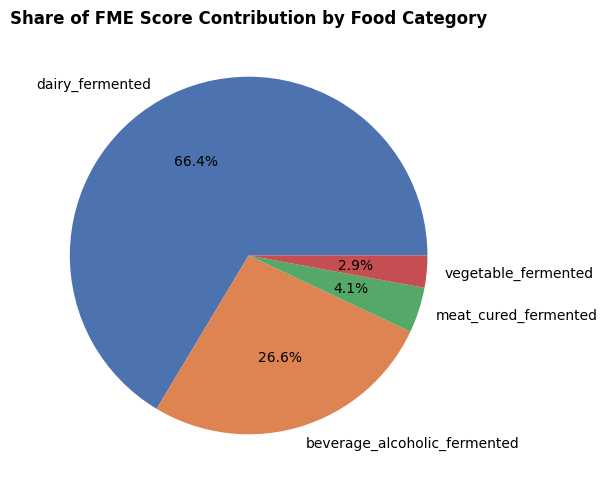

In [16]:
contribution_by_category = (
    exposure_by_category.groupby("food_category_unified")["WeightedExposure"]
    .sum()
)
contribution_share = (contribution_by_category / contribution_by_category.sum() * 100).round(1)

print("Share of total FME weighted exposure, by category:")
print(contribution_share.sort_values(ascending=False))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 6))
contribution_share.sort_values(ascending=False).plot.pie(
    ax=ax, autopct="%1.1f%%", colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
)
ax.set_ylabel("")
ax.set_title("Share of FME Score Contribution by Food Category", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 4c: Re-define FME using within-category normalization

The raw FME score is dominated by dairy (66%) simply because dairy has the
most matched eating events, not because it is more microbially meaningful.
We re-define the score so each category contributes a comparable, relative
signal: weighted exposure is z-scored within its own category (across all
sample-days that have any exposure to it) before summing across categories.

This means the new FME score answers: "how unusually high was this person's
exposure to fermented foods today, relative to typical exposure in each
category" - rather than "how many total grams of fermented food, weighted
by richness, did they eat".

In [17]:
exposure_by_category["WeightedExposure_z"] = (
    exposure_by_category.groupby("food_category_unified")["WeightedExposure"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

fme_by_sample_v2 = (
    exposure_by_category.groupby("SampleID")["WeightedExposure_z"]
    .sum()
    .reset_index(name="FME_score_normalized")
)

# Re-check category contribution under the normalized version
contribution_v2 = (
    exposure_by_category.groupby("food_category_unified")["WeightedExposure_z"]
    .apply(lambda x: x.abs().sum())
)
contribution_v2_share = (contribution_v2 / contribution_v2.sum() * 100).round(1)

print("Share of total FME contribution (normalized version), by category:")
print(contribution_v2_share.sort_values(ascending=False))
print()
print("Normalized FME score distribution:")
print(fme_by_sample_v2["FME_score_normalized"].describe())

Share of total FME contribution (normalized version), by category:
food_category_unified
dairy_fermented                 59.2
beverage_alcoholic_fermented    22.1
vegetable_fermented             15.7
meat_cured_fermented             3.0
Name: WeightedExposure_z, dtype: float64

Normalized FME score distribution:
count    3.190000e+02
mean     8.143956e-17
std      1.277987e+00
min     -2.703357e+00
25%     -7.442350e-01
50%     -3.597478e-01
75%      3.323298e-01
max      6.536882e+00
Name: FME_score_normalized, dtype: float64


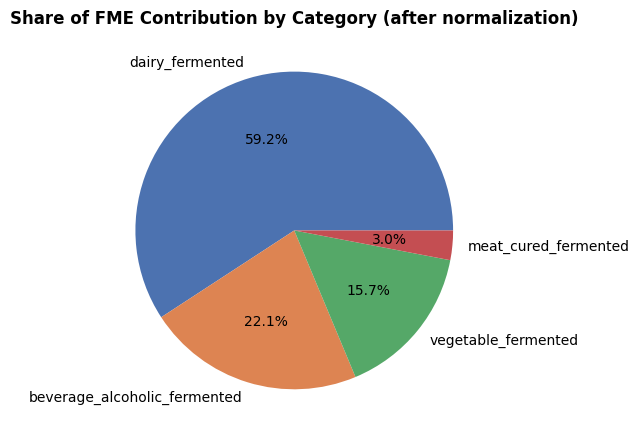

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
contribution_v2_share.sort_values(ascending=False).plot.pie(
    ax=ax, autopct="%1.1f%%", colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
)
ax.set_ylabel("")
ax.set_title("Share of FME Contribution by Category (after normalization)", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 5: Build the temporal backbone (T-1 -> T) and attach FME

To test whether FME on day T-1 is associated with gut changes on day T, we
need:
1. Per-sample gut ecological indices (richness, entropy, etc.) - computed
   from the gut microbiome matrices.
2. A temporal backbone pairing each sample to its immediately preceding
   sample within the same participant.
3. The FME score attached to the PrevSampleID side of each pair (since FME
   describes what was eaten on day T-1, before the gut change on day T).

In [20]:
from scipy.stats import entropy as shannon_entropy

# ---------- Load human-gut metadata and microbiome matrices ----------
metadata = pd.read_csv(BASE / "data" / "maps" / "food_map_no_soy.txt", sep="\t")
metadata["#SampleID"] = metadata["#SampleID"].astype(str)

gut_norm = pd.read_csv(BASE / "data" / "microbiome" / "processed_sample" / "taxonomy_norm_s.txt", sep="\t")
norm_cols = [c for c in gut_norm.columns if c != "#taxonomy"]
gut_norm[norm_cols] = gut_norm[norm_cols].apply(pd.to_numeric, errors="coerce")

# ---------- Per-sample ecological indices ----------
def parse_rank(taxonomy, marker):
    for part in str(taxonomy).split(";"):
        if part.strip().startswith(f"{marker}__"):
            return part.strip()[len(marker) + 2:] or "Unknown"
    return "Unknown"

gut_norm["Family"] = gut_norm["#taxonomy"].apply(lambda t: parse_rank(t, "f"))

index_records = []
for sample_id in norm_cols:
    abundances = gut_norm[sample_id].to_numpy()
    present_mask = abundances > 0
    if present_mask.sum() == 0:
        continue
    present_abundances = abundances[present_mask]
    present_families = gut_norm.loc[present_mask, "Family"]
    family_abundance = present_families.to_frame("Family").assign(ab=present_abundances).groupby("Family")["ab"].sum()
    index_records.append({
        "#SampleID": sample_id,
        "NumTaxa": int(present_mask.sum()),
        "EntropyMicro": float(shannon_entropy(present_abundances)),
        "EntropyFamily": float(shannon_entropy(family_abundance.to_numpy())),
    })

gut_indices = pd.DataFrame(index_records)
print(f"Computed gut indices for {len(gut_indices)} samples.")
gut_indices.head()

C:\Users\winte\AppData\Local\Temp\ipykernel_45580\2485051586.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gut_norm["Family"] = gut_norm["#taxonomy"].apply(lambda t: parse_rank(t, "f"))


Computed gut indices for 483 samples.


,#SampleID,NumTaxa,EntropyMicro,EntropyFamily
0,MCT.f.0002,214,2.862657,1.305867
1,MCT.f.0003,208,3.522780,2.129824
2,MCT.f.0004,213,3.031031,1.657214
3,MCT.f.0005,207,2.974028,1.456498
4,MCT.f.0006,209,3.081194,1.645557


In [21]:
# ---------- Temporal backbone: pair each sample with its preceding one ----------
backbone = metadata[["#SampleID", "UserName", "StudyDayNo"]].copy()
backbone = backbone.sort_values(["UserName", "StudyDayNo"])
backbone["PrevSampleID"] = backbone.groupby("UserName")["#SampleID"].shift(1)
backbone["PrevStudyDayNo"] = backbone.groupby("UserName")["StudyDayNo"].shift(1)
backbone["DayGap"] = backbone["StudyDayNo"] - backbone["PrevStudyDayNo"]

# Keep only consecutive-day transitions (T-1 -> T, DayGap == 1)
temporal_pairs = backbone.dropna(subset=["PrevSampleID"])
temporal_pairs = temporal_pairs.loc[temporal_pairs["DayGap"].eq(1)].copy()

# Attach gut indices for current (T) and previous (T-1) samples
temporal_pairs = temporal_pairs.merge(
    gut_indices.add_suffix("_T"), left_on="#SampleID", right_on="#SampleID_T", how="inner"
).merge(
    gut_indices.add_suffix("_Tminus1"), left_on="PrevSampleID", right_on="#SampleID_Tminus1", how="inner"
)

temporal_pairs["Delta_EntropyMicro"] = temporal_pairs["EntropyMicro_T"] - temporal_pairs["EntropyMicro_Tminus1"]
temporal_pairs["Delta_EntropyFamily"] = temporal_pairs["EntropyFamily_T"] - temporal_pairs["EntropyFamily_Tminus1"]
temporal_pairs["Delta_NumTaxa"] = temporal_pairs["NumTaxa_T"] - temporal_pairs["NumTaxa_Tminus1"]

print(f"Valid consecutive-day transitions: {len(temporal_pairs)}")

# ---------- Attach FME (describes PrevSampleID, i.e. what was eaten before the change) ----------
temporal_pairs = temporal_pairs.merge(
    fme_by_sample_v2.rename(columns={"SampleID": "PrevSampleID"}),
    on="PrevSampleID",
    how="left",
)

print(f"Transitions with a non-missing FME score: {temporal_pairs['FME_score_normalized'].notna().sum()}")
temporal_pairs[["#SampleID", "PrevSampleID", "UserName", "FME_score_normalized", "Delta_EntropyMicro"]].head(10)

Valid consecutive-day transitions: 350
Transitions with a non-missing FME score: 255


,#SampleID,PrevSampleID,UserName,FME_score_normalized,Delta_EntropyMicro
0,MCT.f.0003,MCT.f.0002,MCTs01,-0.393676,0.660123
1,MCT.f.0004,MCT.f.0003,MCTs01,0.105592,-0.491749
2,MCT.f.0005,MCT.f.0004,MCTs01,-0.994673,-0.057004
3,MCT.f.0006,MCT.f.0005,MCTs01,-0.298141,0.107166
4,MCT.f.0007,MCT.f.0006,MCTs01,NaN,-0.053910
5,MCT.f.0008,MCT.f.0007,MCTs01,0.233161,0.056812
6,MCT.f.0009,MCT.f.0008,MCTs01,0.931850,0.038992
7,MCT.f.0010,MCT.f.0009,MCTs01,-1.292586,-0.089960
8,MCT.f.0011,MCT.f.0010,MCTs01,-0.393676,-0.123917
9,MCT.f.0012,MCT.f.0011,MCTs01,-0.519720,0.105689


## Step 5b: Fill missing FME with zero (true absence of exposure, not missing data)

A NaN FME score means the participant ate none of the 4 validated fermented-
food categories that day - this is a real zero-exposure day, not missing
information. Filling with 0 (rather than dropping rows) preserves the
baseline comparison group and avoids biasing the sample toward
fermented-food-eating days only.

In [22]:
temporal_pairs["FME_score_normalized"] = temporal_pairs["FME_score_normalized"].fillna(0)

print(f"Final dataset for modeling: {len(temporal_pairs)} transitions")
print(f"Participants represented: {temporal_pairs['UserName'].nunique()}")
print()
print("FME score distribution (after filling zeros):")
print(temporal_pairs["FME_score_normalized"].describe())
print()
print(f"Zero-exposure days: {(temporal_pairs['FME_score_normalized'] == 0).sum()} "
      f"({100*(temporal_pairs['FME_score_normalized'] == 0).mean():.1f}%)")

Final dataset for modeling: 350 transitions
Participants represented: 32

FME score distribution (after filling zeros):
count    350.000000
mean       0.010724
std        1.076738
min       -2.703357
25%       -0.618687
50%        0.000000
75%        0.045653
max        6.536882
Name: FME_score_normalized, dtype: float64

Zero-exposure days: 95 (27.1%)


## Step 6: Exploratory check - is there any visible relationship at all?

Before fitting any model, we look at the raw relationship between FME
(day T-1) and Delta_EntropyMicro (day T) with a scatter plot and a simple
correlation coefficient. This is a sanity check, not a conclusion - but if
there is no visible trend here, a complex model is unlikely to find one
either.

We use Spearman correlation (not Pearson) because gut microbiome metrics
are typically non-normal and may have a non-linear, monotonic relationship
rather than a strictly linear one.

Spearman correlation: r = -0.077, p = 0.152


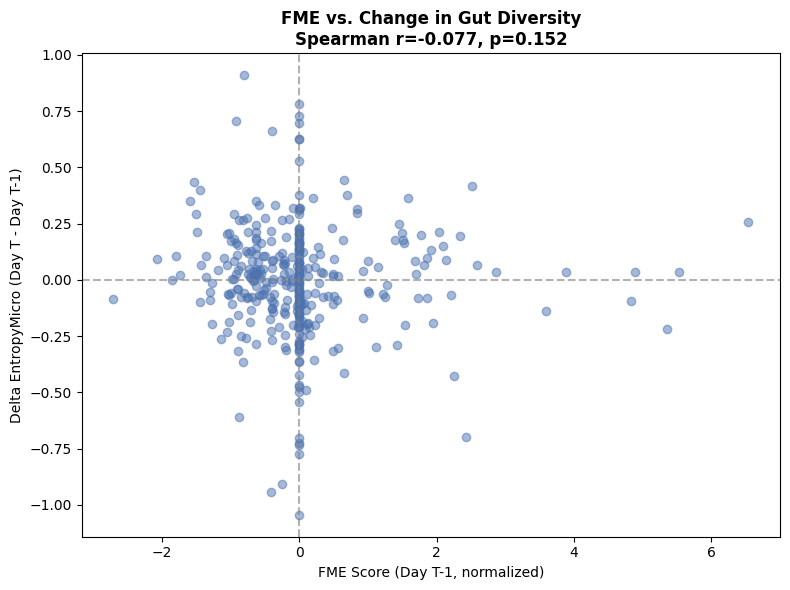

In [23]:
from scipy.stats import spearmanr

corr, pval = spearmanr(temporal_pairs["FME_score_normalized"], temporal_pairs["Delta_EntropyMicro"])
print(f"Spearman correlation: r = {corr:.3f}, p = {pval:.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    temporal_pairs["FME_score_normalized"],
    temporal_pairs["Delta_EntropyMicro"],
    alpha=0.5, color="#4C72B0"
)
ax.axhline(0, color="grey", linestyle="--", alpha=0.6)
ax.axvline(0, color="grey", linestyle="--", alpha=0.6)
ax.set_xlabel("FME Score (Day T-1, normalized)")
ax.set_ylabel("Delta EntropyMicro (Day T - Day T-1)")
ax.set_title(f"FME vs. Change in Gut Diversity\nSpearman r={corr:.3f}, p={pval:.3f}", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 7: Option B - test each food category separately

We pivot the per-category exposure table into 4 separate columns (one per
food_category_unified), fill missing values with 0 (no exposure that day,
same logic as before), and attach them to the temporal backbone. Each
category is then tested independently against Delta_EntropyMicro using
Spearman correlation, so we can see if opposing effects were cancelling
each other out in the unified FME score.

In [24]:
# ---------- Pivot per-category exposure to wide format ----------
category_wide = (
    exposure_by_category
    .pivot_table(index="SampleID", columns="food_category_unified", values="WeightedExposure_z", fill_value=0)
    .reset_index()
)
category_wide.columns = ["SampleID"] + [f"FME_{c}" for c in category_wide.columns[1:]]

print(f"Category-level exposure table: {category_wide.shape}")
category_wide.head()

Category-level exposure table: (319, 5)


,SampleID,FME_beverage_alcoholic_fermented,FME_dairy_fermented,FME_meat_cured_fermented,FME_vegetable_fermented
0,MCT.f.0002,-0.395557,0.001881,0.0,0.000000
1,MCT.f.0003,0.000000,0.105592,0.0,0.000000
2,MCT.f.0004,-0.101523,-0.465171,0.0,-0.427978
3,MCT.f.0005,0.070445,-0.368586,0.0,0.000000
4,MCT.f.0007,0.234665,-0.001504,0.0,0.000000


In [25]:
# ---------- Attach to temporal backbone (same logic as before: PrevSampleID side) ----------
temporal_pairs_b = temporal_pairs.merge(
    category_wide.rename(columns={"SampleID": "PrevSampleID"}),
    on="PrevSampleID",
    how="left",
)

fme_cols = [c for c in temporal_pairs_b.columns if c.startswith("FME_")]
temporal_pairs_b[fme_cols] = temporal_pairs_b[fme_cols].fillna(0)

print(f"Transitions: {len(temporal_pairs_b)}")
print(f"Category columns: {fme_cols}")
print()
for col in fme_cols:
    nonzero = (temporal_pairs_b[col] != 0).sum()
    print(f"  {col}: {nonzero} non-zero days ({100*nonzero/len(temporal_pairs_b):.1f}%)")

Transitions: 350
Category columns: ['FME_score_normalized', 'FME_beverage_alcoholic_fermented', 'FME_dairy_fermented', 'FME_meat_cured_fermented', 'FME_vegetable_fermented']

  FME_score_normalized: 255 non-zero days (72.9%)
  FME_beverage_alcoholic_fermented: 108 non-zero days (30.9%)
  FME_dairy_fermented: 216 non-zero days (61.7%)
  FME_meat_cured_fermented: 13 non-zero days (3.7%)
  FME_vegetable_fermented: 48 non-zero days (13.7%)


## Step 7b: Spearman correlation per category vs. Delta_EntropyMicro

Each category is tested independently. We also apply a simple
Bonferroni-style awareness (4 tests, not 77), so significance should be
interpreted with that in mind rather than treated as 4 independent
fully-corrected results.

                       Category  Spearman_r   p_value
0              score_normalized   -0.076764  0.151830
3          meat_cured_fermented   -0.047882  0.371802
2               dairy_fermented   -0.024542  0.647259
1  beverage_alcoholic_fermented   -0.017201  0.748464
4           vegetable_fermented    0.002200  0.967292


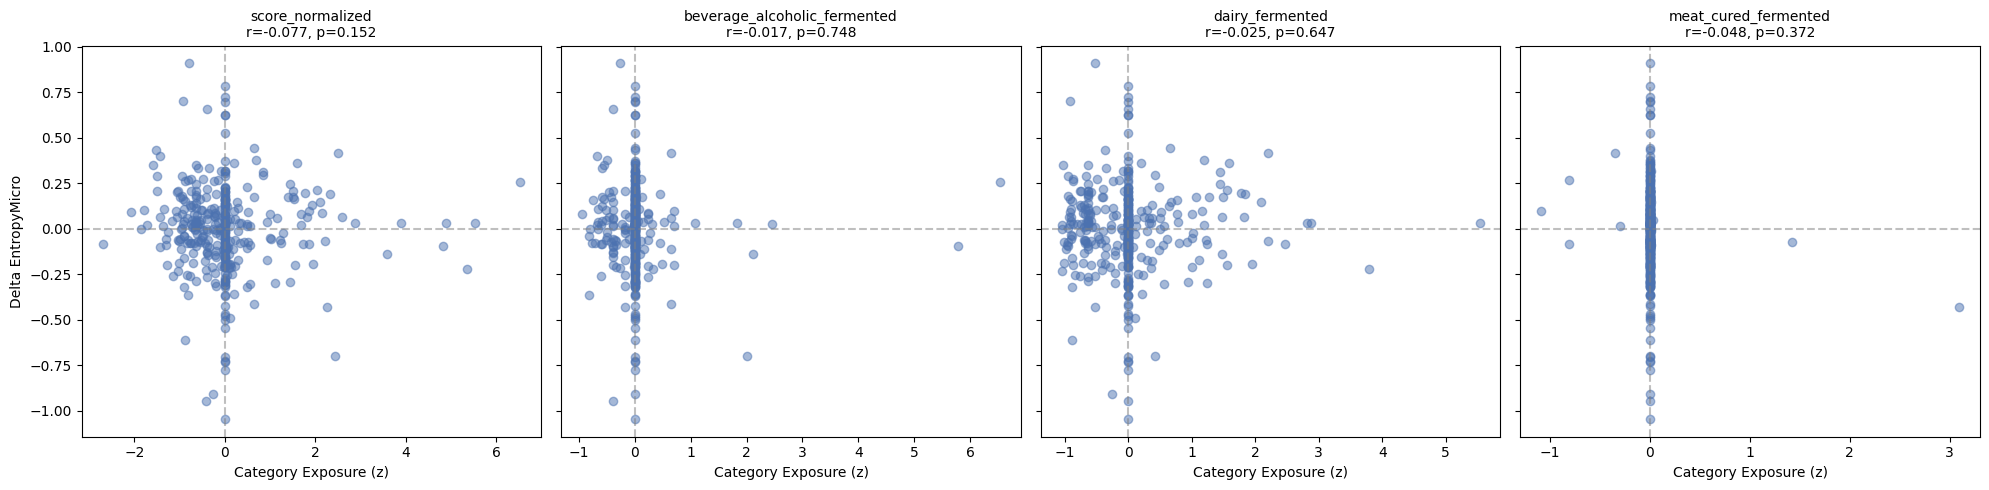

In [26]:
from scipy.stats import spearmanr

results_b = []
for col in fme_cols:
    r, p = spearmanr(temporal_pairs_b[col], temporal_pairs_b["Delta_EntropyMicro"])
    results_b.append({"Category": col.replace("FME_", ""), "Spearman_r": r, "p_value": p})

results_b_df = pd.DataFrame(results_b).sort_values("p_value")
print(results_b_df)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, col in zip(axes, fme_cols):
    ax.scatter(temporal_pairs_b[col], temporal_pairs_b["Delta_EntropyMicro"], alpha=0.5, color="#4C72B0")
    ax.axhline(0, color="grey", linestyle="--", alpha=0.5)
    ax.axvline(0, color="grey", linestyle="--", alpha=0.5)
    r = results_b_df.loc[results_b_df["Category"] == col.replace("FME_", ""), "Spearman_r"].values[0]
    p = results_b_df.loc[results_b_df["Category"] == col.replace("FME_", ""), "p_value"].values[0]
    ax.set_title(f"{col.replace('FME_', '')}\nr={r:.3f}, p={p:.3f}", fontsize=10)
    ax.set_xlabel("Category Exposure (z)")
axes[0].set_ylabel("Delta EntropyMicro")
plt.tight_layout()
plt.show()

## Step 8: Per-participant relationship - is the group-level null hiding personalized responses?

Johnson et al. 2019 (one of the project's reference papers) found that
diet-microbiome associations are highly personalized - the same food can
have opposite effects in different people. We test this by computing a
separate Spearman correlation between FME and Delta_EntropyMicro for each
participant individually (using the unified FME score), restricted to
participants with enough transitions to make a correlation meaningful.

In [27]:
MIN_TRANSITIONS = 6  # minimum transitions per participant to compute a meaningful correlation

per_user_results = []
for user, group in temporal_pairs.groupby("UserName"):
    if len(group) < MIN_TRANSITIONS:
        continue
    r, p = spearmanr(group["FME_score_normalized"], group["Delta_EntropyMicro"])
    per_user_results.append({
        "UserName": user,
        "NumTransitions": len(group),
        "Spearman_r": r,
        "p_value": p,
    })

per_user_df = pd.DataFrame(per_user_results).sort_values("Spearman_r")
print(f"Participants with >= {MIN_TRANSITIONS} transitions: {len(per_user_df)}")
print()
print(per_user_df.to_string(index=False))

Participants with >= 6 transitions: 29

UserName  NumTransitions  Spearman_r  p_value
  MCTs15               6   -0.828571 0.041563
  MCTs16              10   -0.747724 0.012900
  MCTs13               6   -0.654654 0.158302
  MCTs34               7   -0.535714 0.215217
  MCTs27              11   -0.423691 0.194089
  MCTs04              12   -0.352121 0.261643
  MCTs22              12   -0.290592 0.359511
  MCTs31              12   -0.283657 0.371608
  MCTs25              13   -0.274725 0.363675
  MCTs28               7   -0.204124 0.660642
  MCTs32              10   -0.184637 0.609596
  MCTs26              16   -0.117777 0.663991
  MCTs19              12   -0.099660 0.757962
  MCTs14              14   -0.083608 0.776284
  MCTs36              16   -0.071520 0.792389
  MCTs01              13   -0.063274 0.837296
  MCTs03               8   -0.047619 0.910849
  MCTs10              11    0.027273 0.936558
  MCTs18              16    0.081728 0.763493
  MCTs21              13    0.169559 0.5

C:\Users\winte\AppData\Local\Temp\ipykernel_45580\1186115.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(group["FME_score_normalized"], group["Delta_EntropyMicro"])


## Step 8b: Visualize per-participant correlation spread

If responses are personalized (some participants positive, some negative,
roughly cancelling out in the group average), we expect to see a wide spread
of r-values across participants, possibly with a few individually
significant (p < 0.05) results even though the group-level test was null.

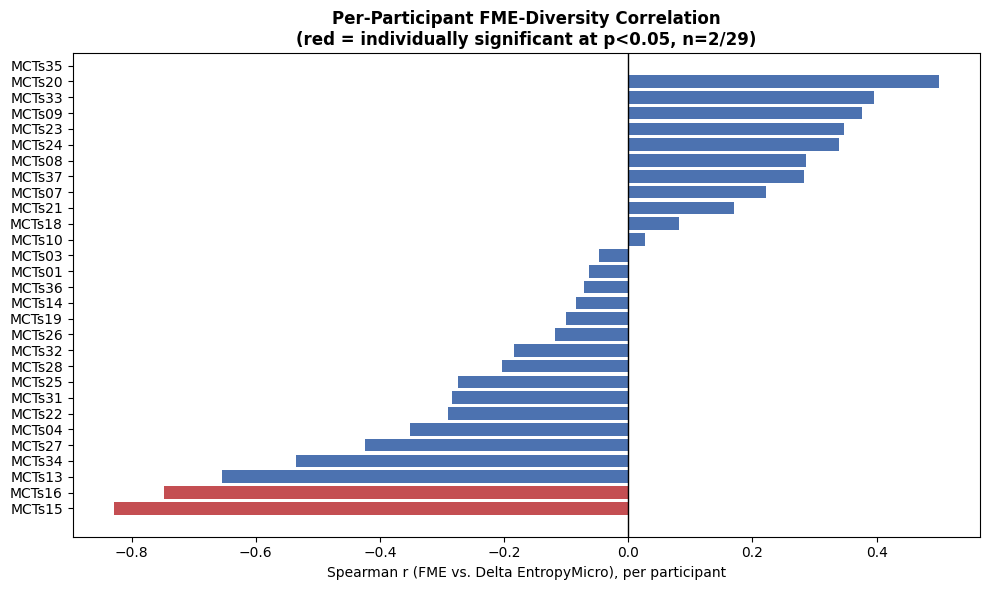

Participants with individually significant correlation (p<0.05): 2 / 29
Positive r: 11  |  Negative r: 17


In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52" if p < 0.05 else "#4C72B0" for p in per_user_df["p_value"]]
ax.barh(per_user_df["UserName"], per_user_df["Spearman_r"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman r (FME vs. Delta EntropyMicro), per participant")
ax.set_title(
    f"Per-Participant FME-Diversity Correlation\n"
    f"(red = individually significant at p<0.05, n={(per_user_df['p_value'] < 0.05).sum()}/{len(per_user_df)})",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"Participants with individually significant correlation (p<0.05): {(per_user_df['p_value'] < 0.05).sum()} / {len(per_user_df)}")
print(f"Positive r: {(per_user_df['Spearman_r'] > 0).sum()}  |  Negative r: {(per_user_df['Spearman_r'] < 0).sum()}")

## Step 9: Predict Supplement Arm (MCT vs EVOO) from gut microbiome + FME

Research question: can we predict which supplement arm a participant was
assigned to, from their gut microbiome state and dietary fermented-food
exposure?

Critical methodological point: Supplement is constant per participant for
the entire study (it does not vary day-to-day). A naive random row-level
train/test split would let the model see the same participant's microbiome
in both train and test, allowing it to "memorize" individual identity rather
than learn anything about diet/microbiome effects. We use a participant-level
(grouped) split to prevent this leakage.

In [29]:
# ---------- Verify Supplement is indeed constant per participant ----------
supplement_per_user = metadata.groupby("UserName")["Supplement"].nunique()
print("Participants with more than one Supplement value (should be 0):")
print((supplement_per_user > 1).sum())
print()
print(metadata.groupby("UserName")["Supplement"].first().value_counts())

Participants with more than one Supplement value (should be 0):
0

Supplement
EVOO    16
MCT     16
Name: count, dtype: int64


## Step 9b: Build the feature matrix for the MCT vs EVOO classification

Features combine three sources, all describing the state at/around day T-1
(before the supplement label, which is constant, so this is really testing
whether the gut + diet *state* differs systematically between arms):
- Gut ecological indices at T-1 (NumTaxa, EntropyMicro, EntropyFamily)
- Delta indices (T - T-1): captures dynamics, not just a snapshot
- FME score (unified) and the 4 per-category exposures

Target: Supplement (binary, MCT=1 / EVOO=0). One row per transition (350
total), but participants will be split as whole groups, not rows.

In [30]:
model_df = temporal_pairs_b.merge(
    metadata[["#SampleID", "Supplement"]].rename(columns={"#SampleID": "PrevSampleID"}),
    on="PrevSampleID",
    how="left",
)

feature_cols = [
    "NumTaxa_Tminus1", "EntropyMicro_Tminus1", "EntropyFamily_Tminus1",
    "Delta_EntropyMicro", "Delta_EntropyFamily", "Delta_NumTaxa",
    "FME_score_normalized",
    "FME_beverage_alcoholic_fermented", "FME_dairy_fermented",
    "FME_meat_cured_fermented", "FME_vegetable_fermented",
]

model_df = model_df.dropna(subset=feature_cols + ["Supplement"])
model_df["Supplement_MCT"] = (model_df["Supplement"] == "MCT").astype(int)

print(f"Final modeling dataset: {len(model_df)} rows, {model_df['UserName'].nunique()} participants")
print()
print("Class balance:")
print(model_df["Supplement_MCT"].value_counts())
print()
print("Per-participant row counts (sanity check before grouped split):")
print(model_df.groupby("UserName").size().describe())

Final modeling dataset: 350 rows, 32 participants

Class balance:
Supplement_MCT
1    185
0    165
Name: count, dtype: int64

Per-participant row counts (sanity check before grouped split):
count    32.00000
mean     10.93750
std       4.22693
min       1.00000
25%       7.75000
50%      12.00000
75%      14.00000
max      16.00000
dtype: float64


## Step 10: Train with participant-level (grouped) cross-validation

We use GroupKFold (grouping by UserName) instead of a standard random split,
so that every fold tests on participants the model never saw during
training. This is the only way to know whether the model learned something
about diet/microbiome dynamics, rather than memorizing individual identity.

A Random Forest classifier is used as a first baseline (matches the
project's existing modeling conventions), with class_weight='balanced'
since the split is not guaranteed to stay perfectly 50/50 in every fold.

In [31]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

X = model_df[feature_cols]
y = model_df["Supplement_MCT"]
groups = model_df["UserName"]

gkf = GroupKFold(n_splits=5)

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
)

y_pred = cross_val_predict(rf, X, y, cv=gkf, groups=groups)
y_proba = cross_val_predict(rf, X, y, cv=gkf, groups=groups, method="predict_proba")[:, 1]

acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred, average="macro")
auc = roc_auc_score(y, y_proba)

print(f"Grouped 5-fold CV (by participant) results:")
print(f"  Accuracy : {acc:.3f}")
print(f"  F1-macro : {f1:.3f}")
print(f"  AUC-ROC  : {auc:.3f}")
print()
print("Confusion matrix:")
print(confusion_matrix(y, y_pred))

Grouped 5-fold CV (by participant) results:
  Accuracy : 0.631
  F1-macro : 0.629
  AUC-ROC  : 0.698

Confusion matrix:
[[ 95  70]
 [ 59 126]]


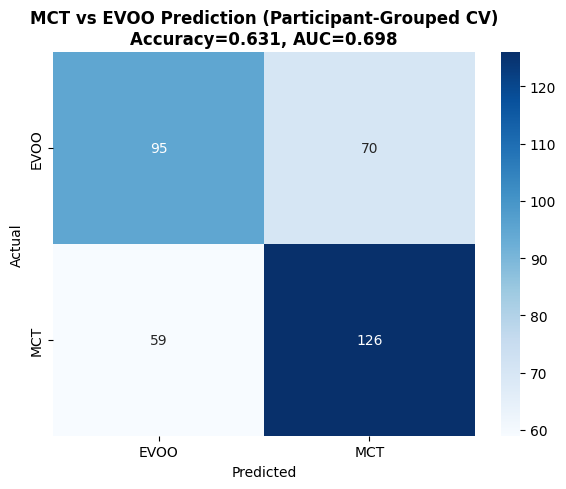

In [32]:
import seaborn as sns

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["EVOO", "MCT"], yticklabels=["EVOO", "MCT"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"MCT vs EVOO Prediction (Participant-Grouped CV)\nAccuracy={acc:.3f}, AUC={auc:.3f}", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 11: Feature importance - what actually drives the prediction?

We fit the Random Forest on the full dataset (for interpretability purposes
only - the CV results above remain the valid performance estimate) and
inspect feature importances, to see whether FME contributes meaningfully or
whether the signal comes entirely from the raw gut microbiome state.

                             Feature  Importance
2              EntropyFamily_Tminus1    0.234901
1               EntropyMicro_Tminus1    0.179095
3                 Delta_EntropyMicro    0.098700
0                    NumTaxa_Tminus1    0.096914
4                Delta_EntropyFamily    0.092399
5                      Delta_NumTaxa    0.088432
8                FME_dairy_fermented    0.075059
6               FME_score_normalized    0.073252
7   FME_beverage_alcoholic_fermented    0.041891
10           FME_vegetable_fermented    0.016162
9           FME_meat_cured_fermented    0.003194


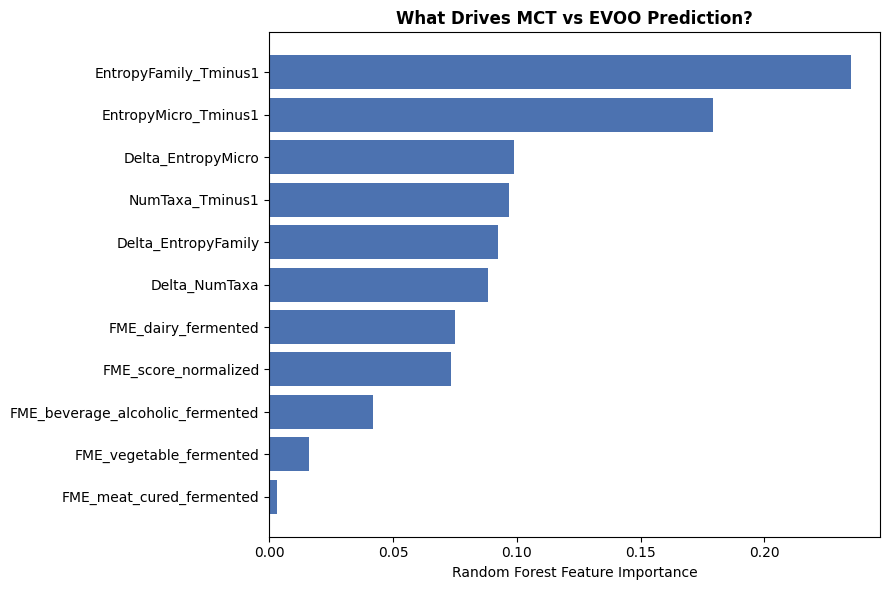

In [33]:
rf_full = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf_full.fit(X, y)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_full.feature_importances_,
}).sort_values("Importance", ascending=False)

print(importance_df)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1], color="#4C72B0")
ax.set_xlabel("Random Forest Feature Importance")
ax.set_title("What Drives MCT vs EVOO Prediction?", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 12: Multi-algorithm comparison (with proper participant-grouped CV)

We compare Random Forest, Gradient Boosting, XGBoost, and LightGBM using the
same GroupKFold (grouped by UserName) for every algorithm, to keep the
comparison fair and leakage-free. This mirrors the project's existing
evaluation conventions, but fixes the missing participant-grouping that the
earlier evaluation.ipynb did not apply.

In [42]:
!pip install xgboost lightgbm --quiet

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False

def make_classifiers():
    clfs = {
        "Random Forest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
        ),
    }
    if XGB_AVAILABLE:
        clfs["XGBoost"] = XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            random_state=42, n_jobs=-1, eval_metric="logloss"
        )
    if LGB_AVAILABLE:
        clfs["LightGBM"] = LGBMClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
        )
    return clfs

print(f"XGBoost available: {XGB_AVAILABLE}  |  LightGBM available: {LGB_AVAILABLE}")

XGBoost available: True  |  LightGBM available: True


In [44]:
results_algo = []
for name, clf in make_classifiers().items():
    y_pred_algo = cross_val_predict(clf, X, y, cv=gkf, groups=groups)
    y_proba_algo = cross_val_predict(clf, X, y, cv=gkf, groups=groups, method="predict_proba")[:, 1]

    results_algo.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y, y_pred_algo),
        "F1_macro": f1_score(y, y_pred_algo, average="macro"),
        "AUC": roc_auc_score(y, y_proba_algo),
    })
    print(f"{name}: done")

results_algo_df = pd.DataFrame(results_algo).sort_values("AUC", ascending=False)
print()
print(results_algo_df.round(4))

Random Forest: done
Gradient Boosting: done
XGBoost: done
LightGBM: done

           Algorithm  Accuracy  F1_macro     AUC
2            XGBoost    0.6600    0.6562  0.7114
3           LightGBM    0.6371    0.6343  0.7044
1  Gradient Boosting    0.6400    0.6366  0.6986
0      Random Forest    0.6314    0.6285  0.6975


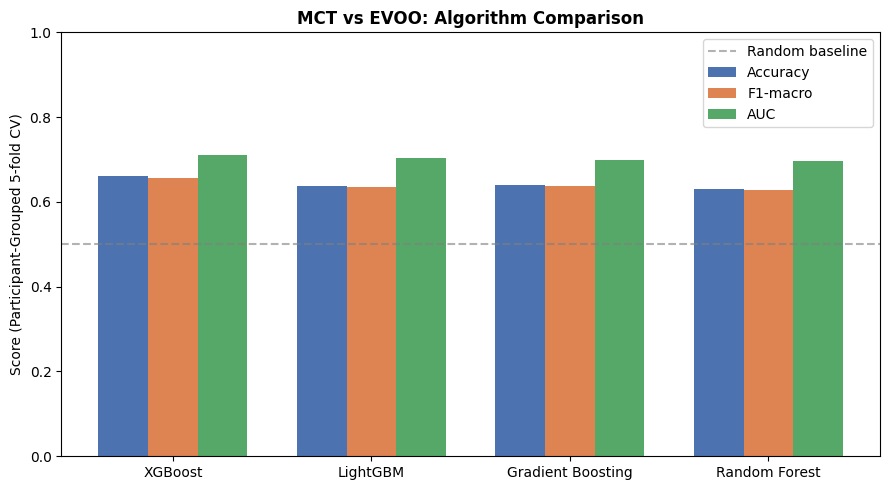

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(results_algo_df))
width = 0.25

ax.bar(x_pos - width, results_algo_df["Accuracy"], width, label="Accuracy", color="#4C72B0")
ax.bar(x_pos, results_algo_df["F1_macro"], width, label="F1-macro", color="#DD8452")
ax.bar(x_pos + width, results_algo_df["AUC"], width, label="AUC", color="#55A868")

ax.axhline(0.5, color="grey", linestyle="--", alpha=0.6, label="Random baseline")
ax.set_xticks(x_pos)
ax.set_xticklabels(results_algo_df["Algorithm"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score (Participant-Grouped 5-fold CV)")
ax.set_title("MCT vs EVOO: Algorithm Comparison", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Step 13: Feature importance for the selected model (XGBoost)

Confirm whether the conclusion about FME's modest contribution (compared to
the gut's own baseline state) holds with the best-performing algorithm too,
not just Random Forest.

                             Feature  Importance
2              EntropyFamily_Tminus1    0.215806
1               EntropyMicro_Tminus1    0.146501
0                    NumTaxa_Tminus1    0.117413
8                FME_dairy_fermented    0.105372
7   FME_beverage_alcoholic_fermented    0.092992
4                Delta_EntropyFamily    0.077985
5                      Delta_NumTaxa    0.076185
3                 Delta_EntropyMicro    0.070863
6               FME_score_normalized    0.056270
10           FME_vegetable_fermented    0.040612
9           FME_meat_cured_fermented    0.000000


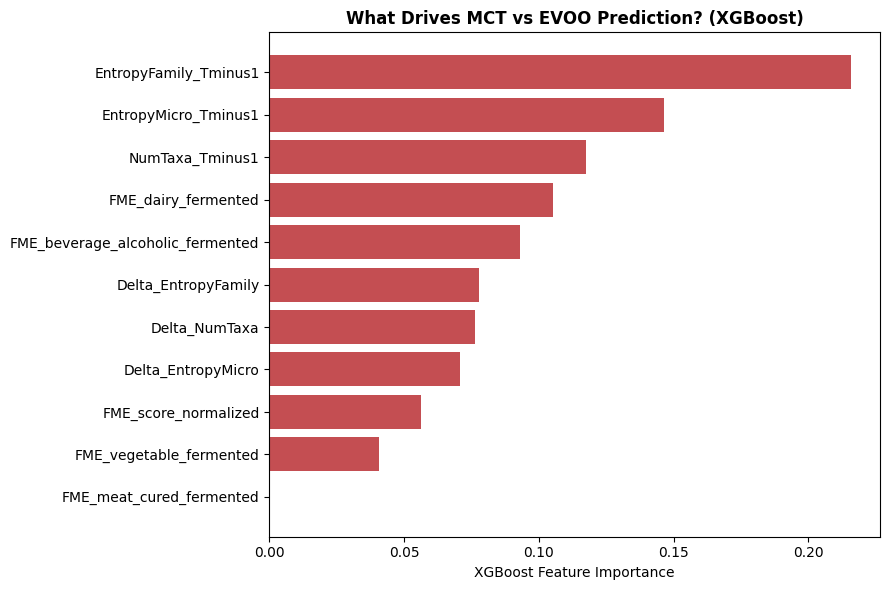

In [46]:
xgb_full = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric="logloss"
)
xgb_full.fit(X, y)

importance_xgb = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_full.feature_importances_,
}).sort_values("Importance", ascending=False)

print(importance_xgb)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_xgb["Feature"][::-1], importance_xgb["Importance"][::-1], color="#C44E52")
ax.set_xlabel("XGBoost Feature Importance")
ax.set_title("What Drives MCT vs EVOO Prediction? (XGBoost)", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 14: Retry the original research question with a richer feature set

Goal: directly predict a gut ecosystem change metric (Delta_EntropyMicro) at
day T from day T-1 information, using FME PLUS additional context that the
earlier attempt did not include: Supplement arm (MCT/EVOO) and macro-
nutrient intake at T-1. This gives the model access to known structural
factors (the study's own designed intervention) alongside the dietary
fermented-food signal, rather than testing FME in isolation.

We also switch from a continuous regression target to a binary "did
diversity increase or decrease" classification, since the earlier
regression attempts in modeling.ipynb/evaluation.ipynb had consistently
negative R2 - a binary framing is a more realistic target given the noise
level in this data.

In [47]:
# ---------- Load nutrition totals (macro-nutrients per day) ----------
nutr = pd.read_csv("dietstudy_data" / Path("diet") / "nutrition_totals.txt", sep="\t") \
    if (Path("dietstudy_data") / "diet" / "nutrition_totals.txt").exists() else None

print(Path("dietstudy_data/diet").exists())
print(list(Path("dietstudy_data/diet").glob("*"))) if Path("dietstudy_data/diet").exists() else None

True
[WindowsPath('dietstudy_data/diet/diet.fiber.txt'), WindowsPath('dietstudy_data/diet/diet.taxonomy.txt'), WindowsPath('dietstudy_data/diet/nutrition_totals.txt'), WindowsPath('dietstudy_data/diet/nutr_65.txt')]


## Step 14b: Inspect nutrition_totals.txt structure

In [48]:
nutr = pd.read_csv("dietstudy_data/diet/nutrition_totals.txt", sep="\t")
print(nutr.shape)
print(nutr.columns.tolist())
nutr.head()

(580, 107)
['X.SampleID', 'UserName', 'StudyDayNo', 'RecordDayNo', 'KCAL', 'PROT', 'TFAT', 'CARB', 'MOIS', 'ALC', 'CAFF', 'THEO', 'SUGR', 'FIBE', 'CALC', 'IRON', 'MAGN', 'PHOS', 'POTA', 'SODI', 'ZINC', 'COPP', 'SELE', 'VC', 'VB1', 'VB2', 'NIAC', 'VB6', 'FOLA', 'FA', 'FF', 'FDFE', 'VB12', 'VARA', 'RET', 'BCAR', 'ACAR', 'CRYP', 'LYCO', 'LZ', 'ATOC', 'VK', 'CHOLE', 'SFAT', 'S040', 'S060', 'S080', 'S100', 'S120', 'S140', 'S160', 'S180', 'MFAT', 'M161', 'M181', 'M201', 'M221', 'PFAT', 'P182', 'P183', 'P184', 'P204', 'P205', 'P225', 'P226', 'VITD', 'CHOLN', 'VITE_ADD', 'B12_ADD', 'F_TOTAL', 'F_CITMLB', 'F_OTHER', 'F_JUICE', 'V_TOTAL', 'V_DRKGR', 'V_REDOR_TOTAL', 'V_REDOR_TOMATO', 'V_REDOR_OTHER', 'V_STARCHY_TOTAL', 'V_STARCHY_POTATO', 'V_STARCHY_OTHER', 'V_OTHER', 'V_LEGUMES', 'G_TOTAL', 'G_WHOLE', 'G_REFINED', 'PF_TOTAL', 'PF_MPS_TOTAL', 'PF_MEAT', 'PF_CUREDMEAT', 'PF_ORGAN', 'PF_POULT', 'PF_SEAFD_HI', 'PF_SEAFD_LOW', 'PF_EGGS', 'PF_SOY', 'PF_NUTSDS', 'PF_LEGUMES', 'D_TOTAL', 'D_MILK', 'D_Y

,X.SampleID,UserName,StudyDayNo,RecordDayNo,KCAL,PROT,TFAT,CARB,MOIS,ALC,...,PF_LEGUMES,D_TOTAL,D_MILK,D_YOGURT,D_CHEESE,OILS,SOLID_FATS,ADD_SUGARS,A_DRINKS,Replicate
0,MCT.f.0001,MCTs01,Day.01,1,1707.040193,95.668747,55.185318,187.965353,3848.605502,14.95872,...,0.0,3.265577,2.05776,0.646,0.561817,14.668870,21.795872,4.822350,1.072512,1
1,MCT.f.0002,MCTs01,Day.02,2,1970.043625,109.619765,53.615264,242.919015,3808.005721,14.04000,...,0.0,4.156035,2.35656,0.646,1.153475,15.886225,19.139825,4.325970,1.008000,1
2,MCT.f.0003,MCTs01,Day.03,3,1714.895330,89.992993,50.561373,234.225138,4183.622433,0.00000,...,0.0,2.979655,1.12608,0.646,1.207575,11.836920,17.711575,4.758330,0.000000,1
3,MCT.f.0004,MCTs01,Day.04,4,2487.232625,94.611953,92.021551,257.539030,4816.211548,42.44800,...,0.0,3.634460,2.15186,0.000,1.482600,55.308100,19.937800,5.917100,3.035200,1
4,MCT.f.0005,MCTs01,Day.05,5,2260.211176,110.268353,95.570253,165.608070,4404.243876,43.93060,...,0.0,3.379710,2.32071,0.000,1.059000,24.231213,54.613613,5.793898,3.116360,1


## Step 14c: Check for duplicate SampleIDs before merging nutrition data

In [49]:
print(f"Total rows: {len(nutr)}")
print(f"Unique X.SampleID: {nutr['X.SampleID'].nunique()}")
print(f"Replicate value counts: {nutr['Replicate'].value_counts().to_dict()}")

Total rows: 580
Unique X.SampleID: 580
Replicate value counts: {1: 580}


## Step 15: Build the enriched feature matrix and binary target

Target: GutDiversityUp (binary) - did EntropyMicro increase from T-1 to T?
This reframes the noisy regression problem as a more learnable binary
question, consistent with how the project's prior modeling.ipynb handled
the analogous "GoodGutDay" target.

Features now include: gut state at T-1, FME (unified + per-category),
Supplement arm (MCT/EVOO, the study's designed intervention), and key
macro-nutrients at T-1 (KCAL, PROT, TFAT, CARB, FIBE) - giving the model
the context that the FME-only attempt lacked.

In [51]:
nutr_features = nutr[["X.SampleID", "KCAL", "PROT", "TFAT", "CARB", "FIBE"]].rename(
    columns={"X.SampleID": "PrevSampleID"}
)
nutr_features.columns = ["PrevSampleID"] + [f"nutr_{c}" for c in nutr_features.columns[1:]]

model_df2 = temporal_pairs_b.merge(
    metadata[["#SampleID", "Supplement"]].rename(columns={"#SampleID": "PrevSampleID"}),
    on="PrevSampleID", how="left"
).merge(
    nutr_features, on="PrevSampleID", how="left"
)

model_df2["Supplement_MCT"] = (model_df2["Supplement"] == "MCT").astype(int)
model_df2["GutDiversityUp"] = (model_df2["Delta_EntropyMicro"] > 0).astype(int)

feature_cols2 = [
    "NumTaxa_Tminus1", "EntropyMicro_Tminus1", "EntropyFamily_Tminus1",
    "FME_score_normalized",
    "FME_beverage_alcoholic_fermented", "FME_dairy_fermented",
    "FME_meat_cured_fermented", "FME_vegetable_fermented",
    "Supplement_MCT",
    "nutr_KCAL", "nutr_PROT", "nutr_TFAT", "nutr_CARB", "nutr_FIBE",
]

model_df2 = model_df2.dropna(subset=feature_cols2 + ["GutDiversityUp"])

print(f"Final dataset: {len(model_df2)} rows, {model_df2['UserName'].nunique()} participants")
print()
print("Target balance (GutDiversityUp):")
print(model_df2["GutDiversityUp"].value_counts())

Final dataset: 350 rows, 32 participants

Target balance (GutDiversityUp):
GutDiversityUp
1    184
0    166
Name: count, dtype: int64


## Step 16: Train and compare algorithms (participant-grouped CV) on the enriched target

Same GroupKFold-by-UserName protocol as before, to keep the comparison
leakage-free and consistent with the rest of the analysis.

In [52]:
X2 = model_df2[feature_cols2]
y2 = model_df2["GutDiversityUp"]
groups2 = model_df2["UserName"]

results_algo2 = []
for name, clf in make_classifiers().items():
    y_pred2 = cross_val_predict(clf, X2, y2, cv=gkf, groups=groups2)
    y_proba2 = cross_val_predict(clf, X2, y2, cv=gkf, groups=groups2, method="predict_proba")[:, 1]

    results_algo2.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y2, y_pred2),
        "F1_macro": f1_score(y2, y_pred2, average="macro"),
        "AUC": roc_auc_score(y2, y_proba2),
    })

results_algo2_df = pd.DataFrame(results_algo2).sort_values("AUC", ascending=False)
print(results_algo2_df.round(4))

           Algorithm  Accuracy  F1_macro     AUC
3           LightGBM    0.5886    0.5872  0.5820
2            XGBoost    0.5486    0.5476  0.5620
0      Random Forest    0.5629    0.5602  0.5610
1  Gradient Boosting    0.5229    0.5208  0.5374


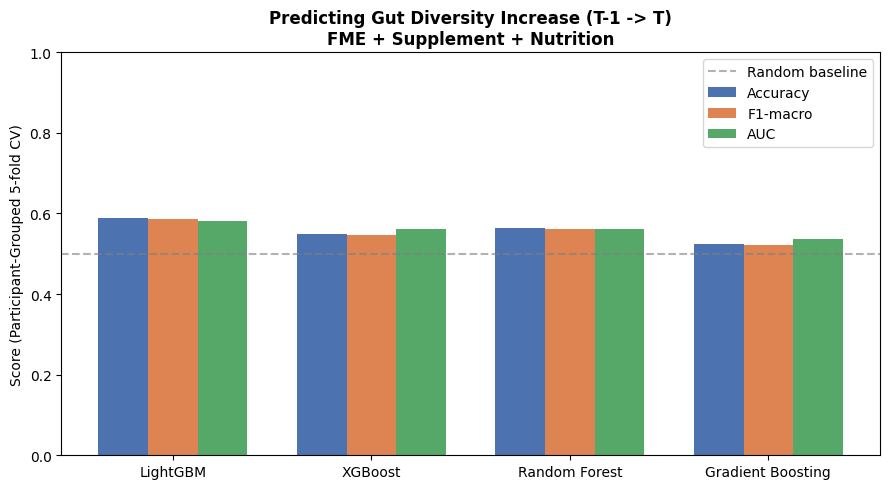

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(results_algo2_df))
width = 0.25

ax.bar(x_pos - width, results_algo2_df["Accuracy"], width, label="Accuracy", color="#4C72B0")
ax.bar(x_pos, results_algo2_df["F1_macro"], width, label="F1-macro", color="#DD8452")
ax.bar(x_pos + width, results_algo2_df["AUC"], width, label="AUC", color="#55A868")

ax.axhline(0.5, color="grey", linestyle="--", alpha=0.6, label="Random baseline")
ax.set_xticks(x_pos)
ax.set_xticklabels(results_algo2_df["Algorithm"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score (Participant-Grouped 5-fold CV)")
ax.set_title("Predicting Gut Diversity Increase (T-1 -> T)\nFME + Supplement + Nutrition", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Step 17: Compute additional gut-change metrics (Stability, Structure)

So far we only tested Diversity (Delta_EntropyMicro) as the target. We add
two more research-question-relevant metrics:
- Stability: NumGainedMicro, NumGoneMicro (taxa appearing/disappearing
  between T-1 and T)
- Structure: Delta_Silhouette (how distinctly taxonomic families separate
  in CLR space, guarded against invalid label configurations)

This lets us check whether any of the 3 research-question dimensions
(stability/diversity/structure) is more learnable than diversity turned
out to be.

In [54]:
from sklearn.metrics import silhouette_score

gut_clr = pd.read_csv(BASE / "data" / "microbiome" / "processed_sample" / "taxonomy_clr_s.txt", sep="\t")
clr_cols = [c for c in gut_clr.columns if c != "#taxonomy"]
gut_clr[clr_cols] = gut_clr[clr_cols].apply(pd.to_numeric, errors="coerce")
gut_clr["Family"] = gut_clr["#taxonomy"].apply(lambda t: parse_rank(t, "f"))

silhouette_records = []
for sample_id in clr_cols:
    present_mask = gut_norm[sample_id].to_numpy() > 0  # reuse NORM presence mask
    clr_vals = gut_clr.loc[present_mask, sample_id].to_numpy()
    families = gut_clr.loc[present_mask, "Family"].to_numpy()
    n_labels = len(set(families))
    sil = np.nan
    if 2 <= n_labels < len(families):
        try:
            sil = silhouette_score(clr_vals.reshape(-1, 1), families)
        except ValueError:
            pass
    silhouette_records.append({"#SampleID": sample_id, "Silhouette": sil})

silhouette_df = pd.DataFrame(silhouette_records)
gut_indices_full = gut_indices.merge(silhouette_df, on="#SampleID", how="left")

print(f"Silhouette computed for {gut_indices_full['Silhouette'].notna().sum()} / {len(gut_indices_full)} samples")
gut_indices_full.head()

C:\Users\winte\AppData\Local\Temp\ipykernel_45580\395782737.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gut_clr["Family"] = gut_clr["#taxonomy"].apply(lambda t: parse_rank(t, "f"))


Silhouette computed for 483 / 483 samples


,#SampleID,NumTaxa,EntropyMicro,EntropyFamily,Silhouette
0,MCT.f.0002,214,2.862657,1.305867,-0.772470
1,MCT.f.0003,208,3.522780,2.129824,-0.769563
2,MCT.f.0004,213,3.031031,1.657214,-0.784554
3,MCT.f.0005,207,2.974028,1.456498,-0.765219
4,MCT.f.0006,209,3.081194,1.645557,-0.797422


In [55]:
# ---------- Rebuild temporal pairs with Silhouette + Gained/Gone ----------
norm_wide = gut_norm.set_index("#taxonomy")[norm_cols]

backbone2 = metadata[["#SampleID", "UserName", "StudyDayNo"]].copy().sort_values(["UserName", "StudyDayNo"])
backbone2["PrevSampleID"] = backbone2.groupby("UserName")["#SampleID"].shift(1)
backbone2["PrevStudyDayNo"] = backbone2.groupby("UserName")["StudyDayNo"].shift(1)
backbone2["DayGap"] = backbone2["StudyDayNo"] - backbone2["PrevStudyDayNo"]
temporal_pairs_full = backbone2.dropna(subset=["PrevSampleID"])
temporal_pairs_full = temporal_pairs_full.loc[temporal_pairs_full["DayGap"].eq(1)].copy()

temporal_pairs_full = temporal_pairs_full.merge(
    gut_indices_full.add_suffix("_T"), left_on="#SampleID", right_on="#SampleID_T", how="inner"
).merge(
    gut_indices_full.add_suffix("_Tminus1"), left_on="PrevSampleID", right_on="#SampleID_Tminus1", how="inner"
)

temporal_pairs_full["Delta_EntropyMicro"] = temporal_pairs_full["EntropyMicro_T"] - temporal_pairs_full["EntropyMicro_Tminus1"]
temporal_pairs_full["Delta_Silhouette"] = temporal_pairs_full["Silhouette_T"] - temporal_pairs_full["Silhouette_Tminus1"]

gained_gone = []
for _, row in temporal_pairs_full.iterrows():
    prev_abun = norm_wide[row["PrevSampleID"]]
    curr_abun = norm_wide[row["#SampleID"]]
    gained = ((prev_abun == 0) & (curr_abun > 0)).sum()
    gone = ((prev_abun > 0) & (curr_abun == 0)).sum()
    gained_gone.append({"#SampleID": row["#SampleID"], "PrevSampleID": row["PrevSampleID"],
                         "NumGainedMicro": gained, "NumGoneMicro": gone})

temporal_pairs_full = temporal_pairs_full.merge(pd.DataFrame(gained_gone), on=["#SampleID", "PrevSampleID"])

print(f"Transitions with all metrics: {len(temporal_pairs_full)}")
print(f"Valid Delta_Silhouette: {temporal_pairs_full['Delta_Silhouette'].notna().sum()}")
temporal_pairs_full[["#SampleID", "PrevSampleID", "Delta_EntropyMicro", "Delta_Silhouette", "NumGainedMicro", "NumGoneMicro"]].head()

Transitions with all metrics: 350
Valid Delta_Silhouette: 350


,#SampleID,PrevSampleID,Delta_EntropyMicro,Delta_Silhouette,NumGainedMicro,NumGoneMicro
0,MCT.f.0003,MCT.f.0002,0.660123,0.002907,1,7
1,MCT.f.0004,MCT.f.0003,-0.491749,-0.014991,6,1
2,MCT.f.0005,MCT.f.0004,-0.057004,0.019334,1,7
3,MCT.f.0006,MCT.f.0005,0.107166,-0.032203,6,4
4,MCT.f.0007,MCT.f.0006,-0.053910,-0.006275,5,2


## Step 18: Compare learnability across 3 research-question dimensions

We define 3 binary targets, one per research-question dimension:
- GutDiversityUp: Delta_EntropyMicro > 0
- GutStable: combined gained+gone taxa below the median (low turnover = stable)
- GutStructureUp: Delta_Silhouette > 0

Same feature set (FME, Supplement, nutrition) and same GroupKFold protocol
for all 3, so the comparison is fair.

In [61]:
model_df3 = temporal_pairs_full.merge(
    metadata[["#SampleID", "UserName", "StudyDayNo"]].rename(columns={"#SampleID": "PrevSampleID"}),
    on="PrevSampleID", how="left", suffixes=("", "_meta")
).merge(
    metadata[["#SampleID", "Supplement"]].rename(columns={"#SampleID": "PrevSampleID"}),
    on="PrevSampleID", how="left"
).merge(
    category_wide.rename(columns={"SampleID": "PrevSampleID"}), on="PrevSampleID", how="left"
).merge(
    fme_by_sample_v2.rename(columns={"SampleID": "PrevSampleID"}), on="PrevSampleID", how="left"
).merge(
    nutr_features, on="PrevSampleID", how="left"
)

fme_cat_cols = [c for c in model_df3.columns if c.startswith("FME_")]
model_df3[fme_cat_cols] = model_df3[fme_cat_cols].fillna(0)
model_df3["Supplement_MCT"] = (model_df3["Supplement"] == "MCT").astype(int)

model_df3["TotalTurnover"] = model_df3["NumGainedMicro"] + model_df3["NumGoneMicro"]
model_df3["GutDiversityUp"] = (model_df3["Delta_EntropyMicro"] > 0).astype(int)
model_df3["GutStable"] = (model_df3["TotalTurnover"] <= model_df3["TotalTurnover"].median()).astype(int)
model_df3["GutStructureUp"] = (model_df3["Delta_Silhouette"] > 0).astype(int)

# Baseline gut state at T-1 (richness/diversity/structure) included this time -
# these were the strongest predictors in the earlier MCT/EVOO model and were
# missing from the previous version of this cell, which made all 3 targets
# look artificially close to random (~0.46-0.51 AUC).
feature_cols3 = (
    ["NumTaxa_Tminus1", "EntropyMicro_Tminus1", "EntropyFamily_Tminus1", "Silhouette_Tminus1"]
    + fme_cat_cols
    + ["Supplement_MCT", "nutr_KCAL", "nutr_PROT", "nutr_TFAT", "nutr_CARB", "nutr_FIBE"]
)

model_df3 = model_df3.dropna(subset=feature_cols3)
print(f"Final dataset: {len(model_df3)} rows, {model_df3['UserName'].nunique()} participants")
for target in ["GutDiversityUp", "GutStable", "GutStructureUp"]:
    print(f"{target} balance: {model_df3[target].value_counts().to_dict()}")

Final dataset: 350 rows, 32 participants
GutDiversityUp balance: {1: 184, 0: 166}
GutStable balance: {1: 178, 0: 172}
GutStructureUp balance: {1: 177, 0: 173}


In [62]:
from lightgbm import LGBMClassifier

comparison_results = []
for target in ["GutDiversityUp", "GutStable", "GutStructureUp"]:
    Xc = model_df3[feature_cols3]
    yc = model_df3[target]
    groupsc = model_df3["UserName"]

    clf = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                          class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
    yc_pred = cross_val_predict(clf, Xc, yc, cv=gkf, groups=groupsc)
    yc_proba = cross_val_predict(clf, Xc, yc, cv=gkf, groups=groupsc, method="predict_proba")[:, 1]

    comparison_results.append({
        "Target": target,
        "Accuracy": accuracy_score(yc, yc_pred),
        "F1_macro": f1_score(yc, yc_pred, average="macro"),
        "AUC": roc_auc_score(yc, yc_proba),
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("AUC", ascending=False)
print(comparison_df.round(4))

           Target  Accuracy  F1_macro     AUC
1       GutStable    0.6829    0.6828  0.7471
2  GutStructureUp    0.5743    0.5743  0.6116
0  GutDiversityUp    0.5600    0.5579  0.5884


## Step 19: Feature importance for the winning target - GutStable

GutStable showed the strongest, most learnable signal (AUC=0.747) among the
3 research-question dimensions. We inspect which features drive it.

                             Feature  Importance
3                 Silhouette_Tminus1         166
0                    NumTaxa_Tminus1         160
11                         nutr_PROT         153
12                         nutr_TFAT         147
2              EntropyFamily_Tminus1         138
14                         nutr_FIBE         109
1               EntropyMicro_Tminus1         106
13                         nutr_CARB          90
8               FME_score_normalized          85
10                         nutr_KCAL          71
5                FME_dairy_fermented          68
4   FME_beverage_alcoholic_fermented          27
7            FME_vegetable_fermented          25
9                     Supplement_MCT          21
6           FME_meat_cured_fermented           0


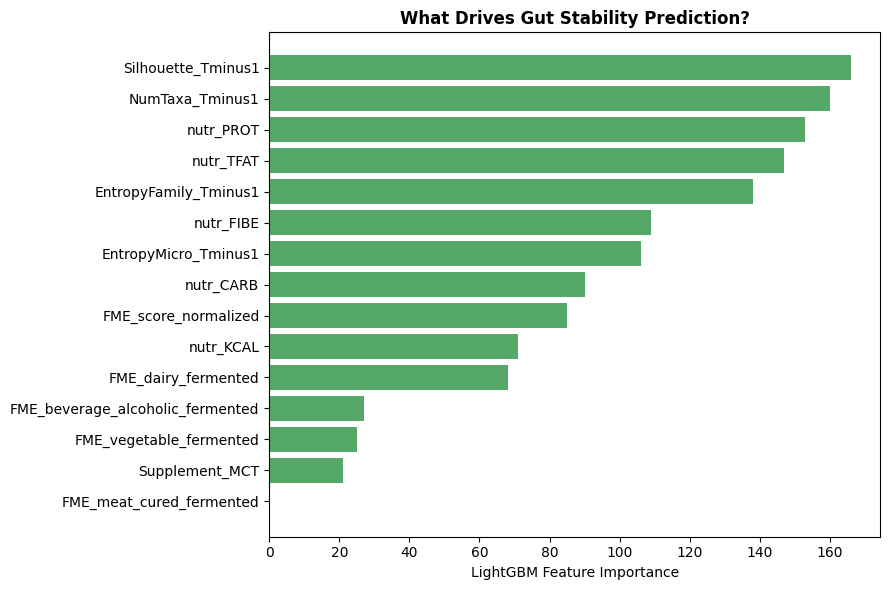

In [63]:
clf_stable = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                             class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
clf_stable.fit(model_df3[feature_cols3], model_df3["GutStable"])

importance_stable = pd.DataFrame({
    "Feature": feature_cols3,
    "Importance": clf_stable.feature_importances_,
}).sort_values("Importance", ascending=False)

print(importance_stable)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_stable["Feature"][::-1], importance_stable["Importance"][::-1], color="#55A868")
ax.set_xlabel("LightGBM Feature Importance")
ax.set_title("What Drives Gut Stability Prediction?", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 20: Permutation test - is each AUC statistically significant?

For each of the 3 targets, we shuffle the labels randomly (breaking any
real relationship between features and target) many times, retrain with
the same GroupKFold protocol each time, and build a null distribution of
AUC scores expected by chance alone. If the real AUC falls in the extreme
tail of this null distribution (empirical p < 0.05), we have evidence the
result is not a statistical artifact of the small, grouped sample.

This is computationally heavier (N_PERMUTATIONS x 5-fold training per
target), so N_PERMUTATIONS is kept moderate (100) to keep runtime
reasonable; the documentation will note this as a limitation if more
permutations would change the conclusion.

In [64]:
import time

N_PERMUTATIONS = 100
rng = np.random.RandomState(42)

def real_auc(X_, y_, groups_):
    clf = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                          class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
    proba = cross_val_predict(clf, X_, y_, cv=gkf, groups=groups_, method="predict_proba")[:, 1]
    return roc_auc_score(y_, proba)

permutation_results = {}

for target in ["GutStable", "GutStructureUp", "GutDiversityUp"]:
    start = time.time()
    Xc = model_df3[feature_cols3]
    yc = model_df3[target].to_numpy()
    groupsc = model_df3["UserName"]

    observed_auc = real_auc(Xc, yc, groupsc)

    null_aucs = []
    for i in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(yc)
        clf = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                              class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
        proba = cross_val_predict(clf, Xc, y_shuffled, cv=gkf, groups=groupsc, method="predict_proba")[:, 1]
        null_aucs.append(roc_auc_score(y_shuffled, proba))

    null_aucs = np.array(null_aucs)
    empirical_p = (null_aucs >= observed_auc).mean()

    permutation_results[target] = {
        "observed_auc": observed_auc,
        "null_mean": null_aucs.mean(),
        "null_std": null_aucs.std(),
        "empirical_p": empirical_p,
        "null_aucs": null_aucs,
    }

    print(f"{target}: observed AUC={observed_auc:.3f}, null mean={null_aucs.mean():.3f} (+/-{null_aucs.std():.3f}), "
          f"empirical p={empirical_p:.3f}  [{time.time()-start:.0f}s]")

GutStable: observed AUC=0.747, null mean=0.497 (+/-0.042), empirical p=0.000  [62s]
GutStructureUp: observed AUC=0.612, null mean=0.495 (+/-0.039), empirical p=0.010  [71s]
GutDiversityUp: observed AUC=0.588, null mean=0.501 (+/-0.040), empirical p=0.010  [73s]
